In [35]:
import numpy as np
import numpy.linalg as la
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import librosa
from scipy.special import softmax
from scipy import stats

Will First try and fit model

In [36]:
df = pd.read_csv("time_series_US_20031231-1800_20260930-1837.csv")
df.head()
y = df['mask'].values

In [37]:
n = len(df)
t = np.arange(n)

c_grid = np.arange(0, n - 1)

cparams = {}
c_covparam = {}
mse = {}

def log_post_c(c):
    X = np.zeros((n,2))
    X[:,0] = 1
    X[:,1] = (t>c).astype(int)
    model = sm.OLS(y,X).fit()
    rss = np.sum(model.resid**2)
    sign, logdet = np.linalg.slogdet(X.T @ X)
    cparams[c] = model.params
    c_covparam[c] = model.cov_params()
    mse[c] = model.mse_resid
    return -.5*logdet - ((n-2)/2)*np.log(rss)

log_post = np.array([log_post_c(c) for c in c_grid])

probs = softmax(log_post)



Part A

Point estimate of c: 191 (last month before change: 2019-12)
95% interval for c: [178, 193] (2018-11 to 2020-02)


Text(0.5, 1.0, 'Posterior of the change point')

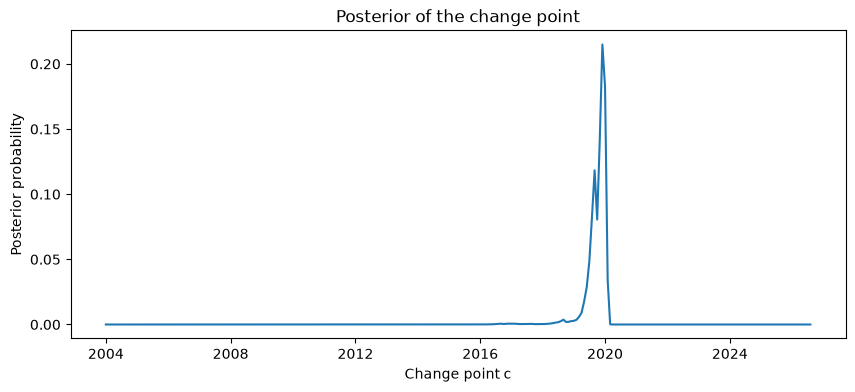

In [38]:
c_hat = c_grid[np.argmax(probs)]

cdf = np.cumsum(probs)
c_lower = c_grid[np.searchsorted(cdf, 0.025)]
c_upper = c_grid[np.searchsorted(cdf, 0.975)]

dates = pd.to_datetime(df['Time'])
print(f"Point estimate of c: {c_hat} (last month before change: {dates[c_hat]:%Y-%m})")
print(f"95% interval for c: [{c_lower}, {c_upper}] "
      f"({dates[c_lower]:%Y-%m} to {dates[c_upper]:%Y-%m})")

plt.figure(figsize=(10, 4))
plt.plot(dates[c_grid], probs)
plt.xlabel('Change point c')
plt.ylabel('Posterior probability')
plt.title('Posterior of the change point')


Part B

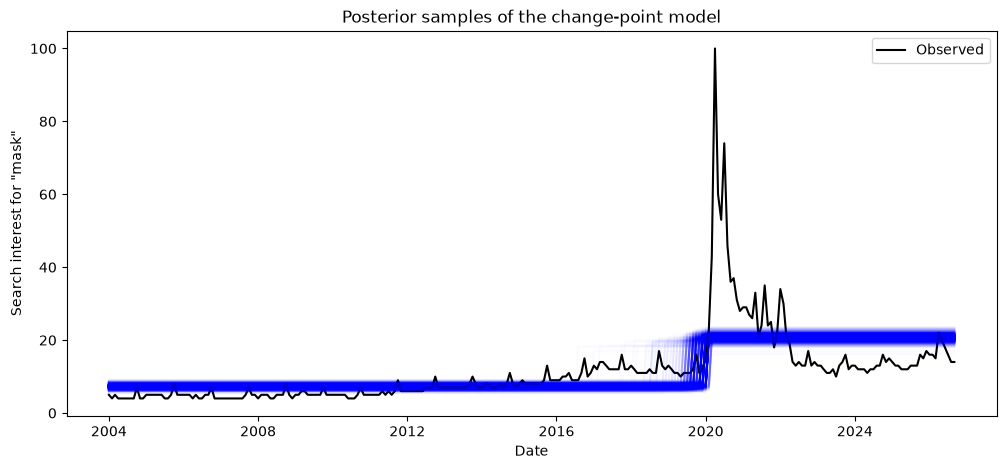

In [39]:
N = 1000
draw = np.zeros((N,3))
for i in range(N):
    c_draw = np.random.choice(c_grid, p=probs)
    beta_hat = cparams[c_draw]
    cov_beta = c_covparam[c_draw]
    s2 = mse[c_draw]
    chi2_draw = np.random.chisquare(df=n-2)
    sigma2_draw = (n-2) * s2 / chi2_draw
    beta_draw = np.random.multivariate_normal(beta_hat,(sigma2_draw/s2)*cov_beta)
    draw[i] = [c_draw, beta_draw[0], beta_draw[1]]

plt.figure(figsize=(12, 5))
plt.plot(dates, y, color='black', label='Observed')

for i in range(N):
    c_i, b0_i, b1_i = draw[i]
    curve = b0_i + b1_i*(t > c_i).astype(int) 
    plt.plot(dates, curve, color='blue', alpha = .02)

plt.xlabel('Date')
plt.ylabel('Search interest for "mask"')
plt.title('Posterior samples of the change-point model')
plt.legend()
plt.show()